In [5]:
import os
import sys
import pandas as pd
import pickle

if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True


In [8]:
from algorithms.benchmark import run_ea

df = pd.read_csv("data/syntheticBinary/binaryManyRoots/Data_Graph_0.csv")

In [10]:
best_graph, best_score = run_ea(df, show_progress=True)

Generation 1/100: Best score = -141335.06
Generation 2/100: Best score = -141289.37
Generation 3/100: Best score = -141280.72
Generation 4/100: Best score = -141237.92
Generation 5/100: Best score = -139700.64
Generation 6/100: Best score = -138714.17
Generation 7/100: Best score = -138559.06
Generation 8/100: Best score = -138411.70
Generation 9/100: Best score = -137409.85
Generation 10/100: Best score = -137409.85
Generation 11/100: Best score = -137164.79
Generation 12/100: Best score = -137155.84
Generation 13/100: Best score = -137139.13
Generation 14/100: Best score = -137023.18
Generation 15/100: Best score = -136260.67
Generation 16/100: Best score = -136220.54
Generation 17/100: Best score = -136216.12
Generation 18/100: Best score = -135540.30
Generation 19/100: Best score = -134241.70
Generation 20/100: Best score = -134236.79
Generation 21/100: Best score = -133517.66
Generation 22/100: Best score = -133462.88
Generation 23/100: Best score = -133252.84
Generation 24/100: B

KeyboardInterrupt: 

In [5]:
best_score

-97079.89595218246

In [6]:
metadata_df = pd.read_csv("data/syntheticBinary/binaryManyRoots/Metadata_Graph_0.csv")
from networkx.algorithms.dag import colliders

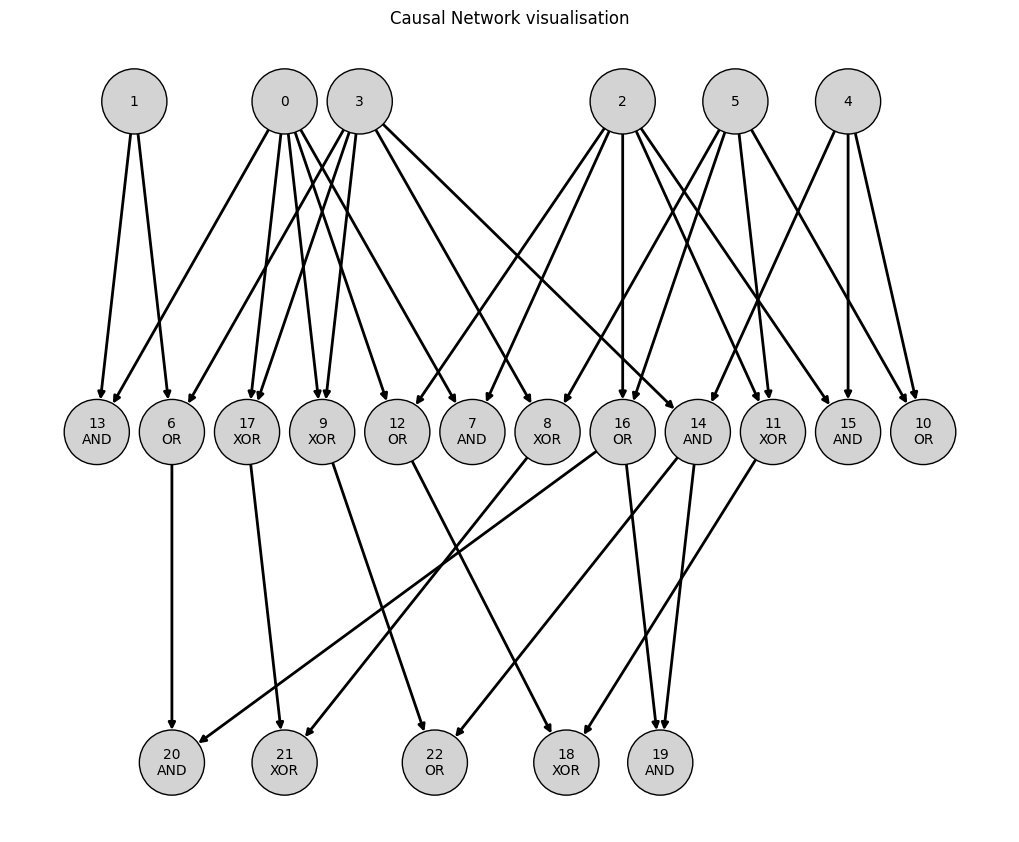

In [7]:
from utils.plotting import GraphVisualization

gv = GraphVisualization(metadata=metadata_df, results=best_graph)
gv.visualize_network_labels()

In [8]:

if "SRV" in metadata_df["Type"].values:
    all_colliders = metadata_df["Combs"] 
    synergistic_colliders = metadata_df[metadata_df["Type"] == "SRV"]["Combs"]
else:
    all_colliders = metadata_df["Combs"]
    synergistic_colliders = metadata_df[metadata_df["Type"] == "XOR"]["Combs"]



In [9]:
synergistic_colliders

2        [3, 5, 8]
3        [0, 3, 9]
5       [2, 5, 11]
11      [0, 3, 17]
12    [11, 12, 18]
15     [8, 17, 21]
Name: Combs, dtype: object

In [10]:

ac_list = [eval(i) for i in all_colliders]
ac_list = [i for i in ac_list if len(i) >= 2]
# match order for learned colliders
for row in ac_list:
    if len(row) >= 2:
        last = row.pop()    # remove last
        row.insert(1, last) # insert at position 1
    

ac_list = [tuple(t) for t in ac_list]
lc_list = list(colliders(best_graph))
lc_list = [tuple(map(int, t)) for t in lc_list]
# print(lc_list)

true_sets = set(ac_list)
learned_sets = set(lc_list)

correct = true_sets & learned_sets
missing = true_sets - learned_sets
extra = learned_sets - true_sets



In [11]:
correct

{(0, 7, 2),
 (0, 9, 3),
 (0, 12, 2),
 (0, 13, 1),
 (0, 17, 3),
 (1, 6, 3),
 (2, 11, 5),
 (2, 15, 4),
 (2, 16, 5),
 (3, 8, 5),
 (4, 10, 5),
 (8, 21, 17),
 (9, 22, 14),
 (11, 18, 12),
 (14, 19, 16)}

In [12]:

# self.colliders_found[idx] = correct
# self.colliders_missing[idx] = missing

# --- Collider metrics (all colliders) ---
tp = len(correct)
fp = len(extra)
fn = len(missing)

collider_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
collider_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
collider_f1 = (2 * collider_precision * collider_recall / (collider_precision + collider_recall)
            if collider_precision + collider_recall > 0 else 0)

# --- Synergistic collider metrics (SC) ---
sc_precision = sc_recall = sc_f1 = 0
sc_list = [eval(t) for t in synergistic_colliders]  # Convert string representations to tuples

for row in sc_list:
    if len(row) >= 2:
        last = row.pop()    # remove last
        row.insert(1, last) # insert at position 1


sc_list = [tuple(t) for t in sc_list]
true_sc = set(sc_list)
correct_sc = true_sc & learned_sets
missing_sc = true_sc - learned_sets
extra_sc = learned_sets - true_sc

tp_sc = len(correct_sc)
fp_sc = len(extra_sc)
fn_sc = len(missing)

# self.sc_found[idx] = correct_sc
# self.sc_missing[idx] = missing_sc

sc_precision = tp_sc / (tp_sc + fp_sc) if (tp_sc + fp_sc) > 0 else 0
sc_recall = tp_sc / (tp_sc + fn_sc) if (tp_sc + fn_sc) > 0 else 0
sc_f1 = (2 * sc_precision * sc_recall / (sc_precision + sc_recall)
        if sc_precision + sc_recall > 0 else 0)
# --- Synergy-only collider metrics (SoC) ---
# soc_precision = soc_recall = soc_f1 = 0


In [13]:
correct_sc

{(0, 9, 3), (0, 17, 3), (2, 11, 5), (3, 8, 5), (8, 21, 17), (11, 18, 12)}